## SECTION 1



In [ ]:
!pip install rasterio ipywidgets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import cv2
import rasterio
from rasterio.enums import Resampling
from scipy import ndimage as ndi
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## SECTION 2: Loading the Satellite Image

A Sentinel-2 image is split into multiple band files. We need 4 bands:
- **B02 = Blue**
- **B03 = Green**  
- **B04 = Red**
- **B08 = Near-Infrared (NIR)**


ALL PARAMETRES

In [ ]:
#Change this path to your SAFE folder
SAFE_PATH = '/content/drive/MyDrive/S2CDATA11/S2A_MSIL2A_20250809T100041_N0511_R122_T32SPC_20250809T135614.SAFE'
SCALE = 10
EPS   = 1e-8

def find_band(folder, band_code):
    for f in os.listdir(folder):
        if f'_{band_code}_' in f and f.endswith('.jp2'):
            return os.path.join(folder, f)
    raise FileNotFoundError(f'Band {band_code} not found!')

def load_band(filepath, scale=10):
    #Load one band, scale it , and normalize to [0, 1].
    with rasterio.open(filepath) as src:
        h = src.height // scale
        w = src.width  // scale
        band = src.read(1, out_shape=(h, w), resampling=Resampling.bilinear)

    return np.clip(band / 10000.0, 0, 1).astype(np.float32)

# Find the image data folder inside the SAFE folder
granule   = os.listdir(os.path.join(SAFE_PATH, 'GRANULE'))[0]
img_folder = os.path.join(SAFE_PATH, 'GRANULE', granule, 'IMG_DATA', 'R10m')

# Load the 4 bands
blue = load_band(find_band(img_folder, 'B02'), SCALE)
green= load_band(find_band(img_folder, 'B03'), SCALE)
red  = load_band(find_band(img_folder, 'B04'), SCALE)
nir  = load_band(find_band(img_folder, 'B08'), SCALE)

print(f'Image loaded Shape: {red.shape}  (height x width in pixels)')
print(f'Each pixel = {SCALE * 10}m x {SCALE * 10}m on the ground')

Image loaded Shape: (1098, 1098)  (height x width in pixels)
Each pixel = 100m x 100m on the ground


## SECTION 3: Visualization and Image Transformations


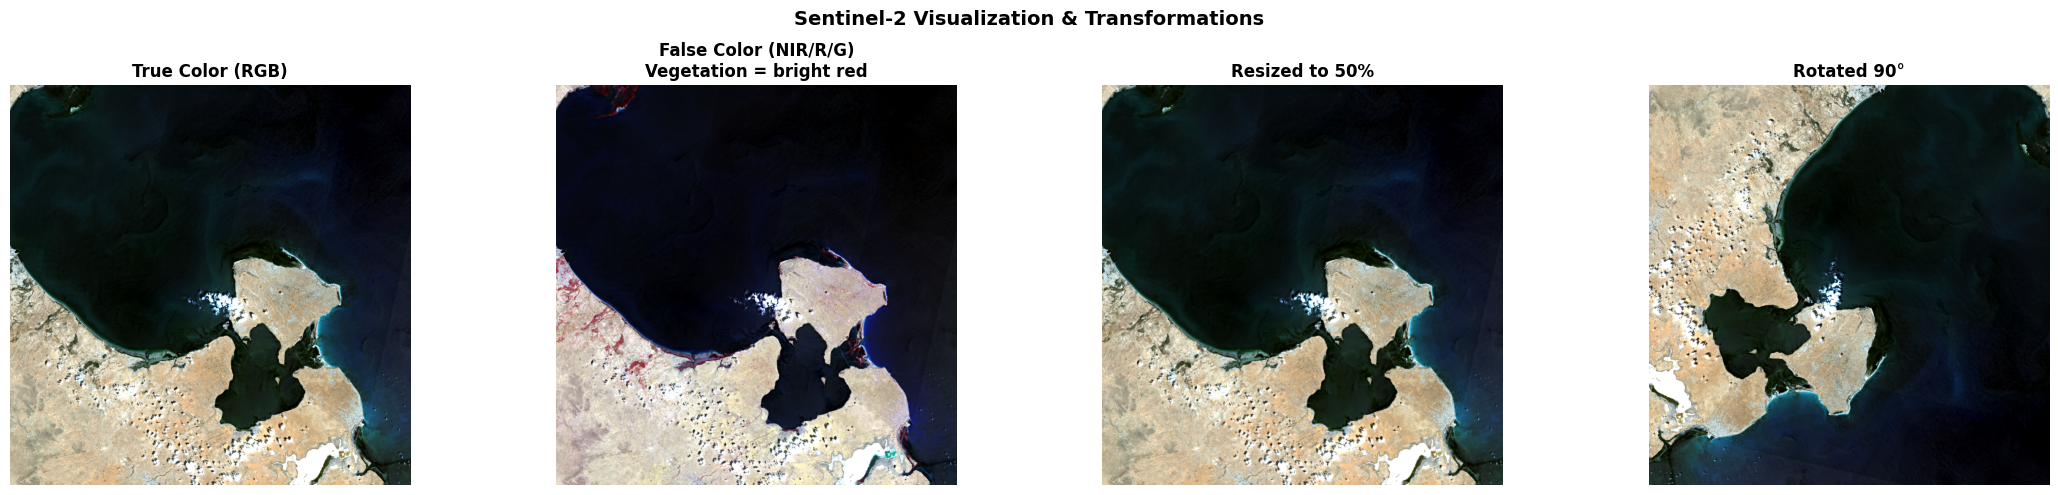

In [ ]:
def stretch(arr):
    lo, hi = np.percentile(arr, 2), np.percentile(arr, 98)
    return np.clip((arr - lo) / (hi - lo + EPS), 0, 1)

def make_rgb(r, g, b):
    return np.stack([stretch(r), stretch(g), stretch(b)], axis=-1)

rgb = make_rgb(red, green, blue)     # True color
fcc = make_rgb(nir, red, green)      # False color (NIR in red channel)

rgb_u8  = (rgb * 255).astype(np.uint8)
rgb_bgr = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2BGR)  # OpenCV uses BGR order

H, W = rgb_u8.shape[:2]
rgb_resized = cv2.resize(rgb_bgr, (W // 2, H // 2))           # 50% smaller
rgb_rotated = cv2.rotate(rgb_bgr, cv2.ROTATE_90_CLOCKWISE)    # 90° rotation

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(rgb)
axes[0].set_title('True Color (RGB)', fontweight='bold')

axes[1].imshow(fcc)
axes[1].set_title('False Color (NIR/R/G)\nVegetation = bright red', fontweight='bold')

axes[2].imshow(cv2.cvtColor(rgb_resized, cv2.COLOR_BGR2RGB))
axes[2].set_title('Resized to 50%', fontweight='bold')

axes[3].imshow(cv2.cvtColor(rgb_rotated, cv2.COLOR_BGR2RGB))
axes[3].set_title('Rotated 90°', fontweight='bold')

for ax in axes: ax.axis('off')
plt.suptitle('Sentinel-2 Visualization & Transformations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## SECTION 4: Spectral Indices


### NDVI: Normalized Difference Vegetation Index
$$NDVI = \frac{NIR - Red}{NIR + Red}$$
- Values close to **+1** → dense vegetation (Posidonia)
- Values close to **0** → bare soil or sand
- Values close to **-1** → water

### NDWI: Normalized Difference Water Index
$$NDWI = \frac{Green - NIR}{Green + NIR}$$
- Values **> 0** → water
- Values **< 0** → land or vegetation


Spectral Index Statistics
NDVI: min=-0.561  max=0.559  mean=0.014  std=0.055
NDWI: min=-0.501  max=0.555  mean=-0.023  std=0.137


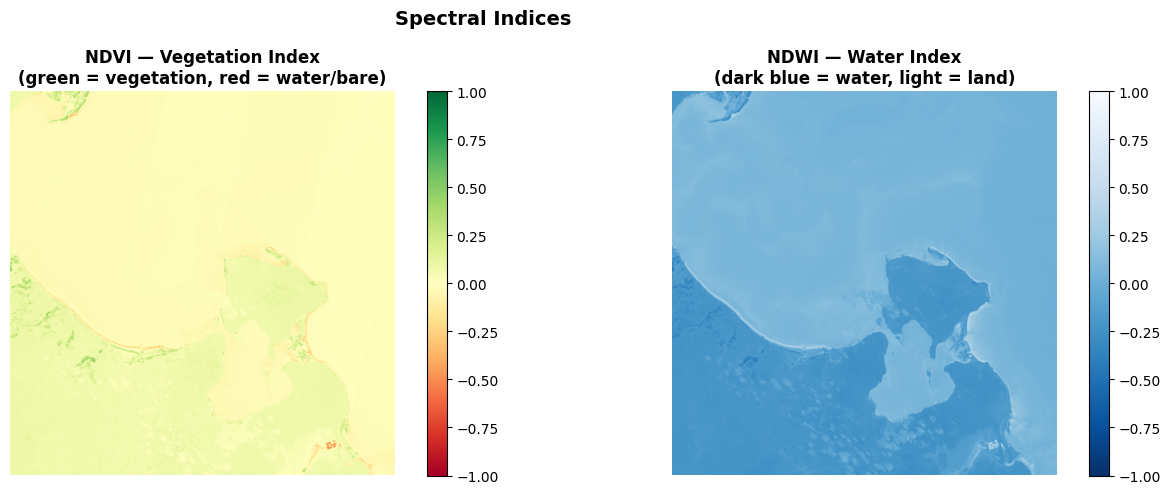

In [ ]:
ndvi = (nir - red) / (nir + red   + EPS)
ndwi = (green - nir) / (green + nir + EPS)

print('Spectral Index Statistics')
for name, arr in [('NDVI', ndvi), ('NDWI', ndwi)]:
    print(f'{name}: min={arr.min():.3f}  max={arr.max():.3f}  '
          f'mean={arr.mean():.3f}  std={arr.std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('NDVI — Vegetation Index\n(green = vegetation, red = water/bare)', fontweight='bold')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(ndwi, cmap='Blues_r', vmin=-1, vmax=1)
axes[1].set_title('NDWI — Water Index\n(dark blue = water, light = land)', fontweight='bold')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

for ax in axes: ax.axis('off')
plt.suptitle('Spectral Indices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## SECTION 5: Image Filtering


In [ ]:
# Convert NDVI to uint8 (0-255)
def to_uint8(arr):
    """Normalize array to 0-255 range."""
    norm = (arr - arr.min()) / (arr.max() - arr.min() + EPS)
    return (norm * 255).astype(np.uint8)

ndvi_u8 = to_uint8(ndvi)
ndwi_u8 = to_uint8(ndwi)

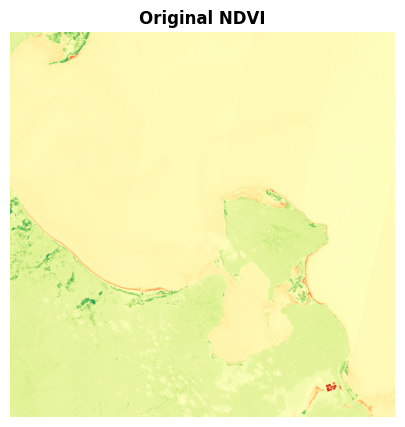

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(ndvi_u8, cmap='RdYlGn')
plt.title('Original NDVI', fontweight='bold')
plt.axis('off')
plt.show()

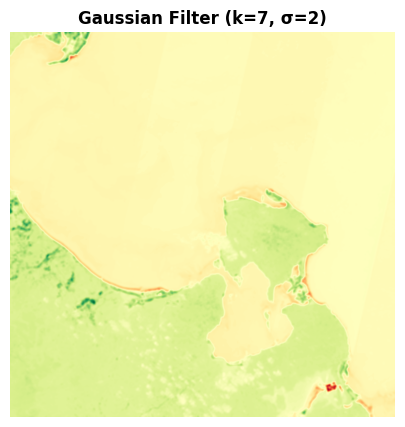

In [ ]:
ndvi_gaussian = cv2.GaussianBlur(ndvi_u8, (7, 7), sigmaX=5)

plt.figure(figsize=(6,5))
plt.imshow(ndvi_gaussian, cmap='RdYlGn')
plt.title('Gaussian Filter (k=7, σ=2)', fontweight='bold')
plt.axis('off')
plt.show()

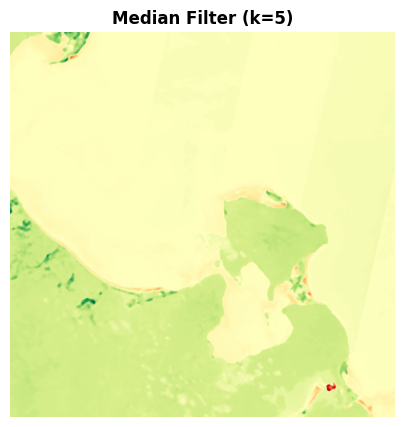

In [ ]:
ndvi_median = cv2.medianBlur(ndvi_u8, 9)

plt.figure(figsize=(6,5))
plt.imshow(ndvi_median, cmap='RdYlGn')
plt.title('Median Filter (k=5)', fontweight='bold')
plt.axis('off')
plt.show()

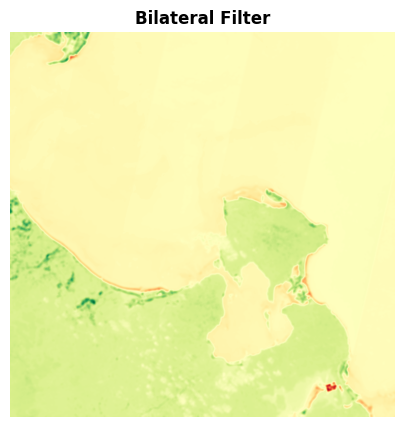

In [ ]:
ndvi_bilateral = cv2.bilateralFilter(ndvi_u8, d=9, sigmaColor=150, sigmaSpace=150)
# d=9 = neighborhood diameter
# sigmaColor=150 = how much color difference is allowed
# sigmaSpace=150 = how far pixels can be and still influence each other
plt.figure(figsize=(6,5))
plt.imshow(ndvi_bilateral, cmap='RdYlGn')
plt.title('Bilateral Filter', fontweight='bold')
plt.axis('off')
plt.show()

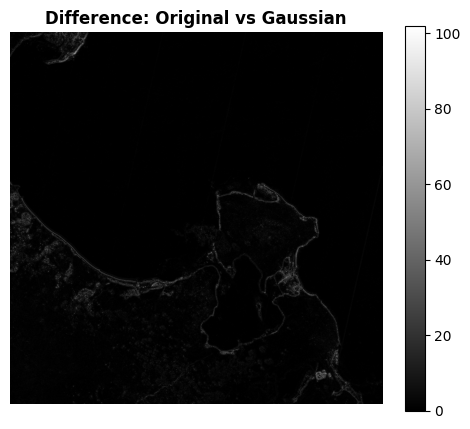

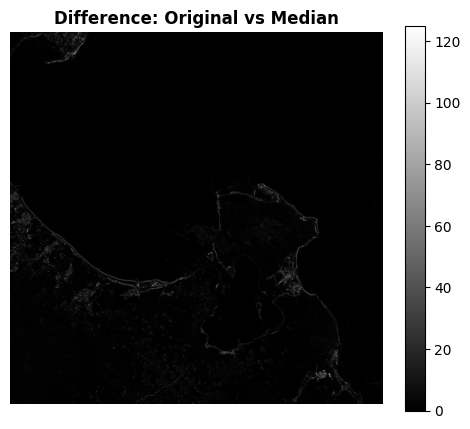

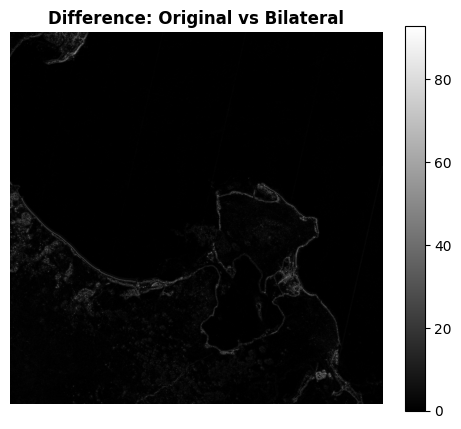

In [ ]:
diff_gaussian = cv2.absdiff(ndvi_u8, ndvi_gaussian)
diff_median = cv2.absdiff(ndvi_u8, ndvi_median)
diff_bilateral = cv2.absdiff(ndvi_u8, ndvi_bilateral)

plt.figure(figsize=(6,5))
plt.imshow(diff_gaussian, cmap='gray')
plt.title('Difference: Original vs Gaussian', fontweight='bold')
plt.axis('off')
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(diff_median, cmap='gray')
plt.title('Difference: Original vs Median', fontweight='bold')
plt.axis('off')
plt.colorbar()
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(diff_bilateral, cmap='gray')
plt.title('Difference: Original vs Bilateral', fontweight='bold')
plt.axis('off')
plt.colorbar()
plt.show()

In [ ]:
print("Gaussian diff:", diff_gaussian.mean())
print("Median diff:", diff_median.mean())
print("Bilateral diff:", diff_bilateral.mean())

Gaussian diff: 1.232793686815903
Median diff: 1.2136024764350484
Bilateral diff: 1.2448415897757472


In [ ]:
ndvi_filt = ndvi_bilateral
ndwi_filt = cv2.bilateralFilter(ndwi_u8, d=9, sigmaColor=75, sigmaSpace=75)

“Bilateral filtering was selected because it reduces noise while preserving important spatial edges (e.g., vegetation-water boundaries), unlike Gaussian filtering which blurs edges.”

---
## SECTION 6: Thresholding and ROI Masking



Otsu threshold for water: 103 (out of 255)
Raw Posidonia detection: 556,425 pixels


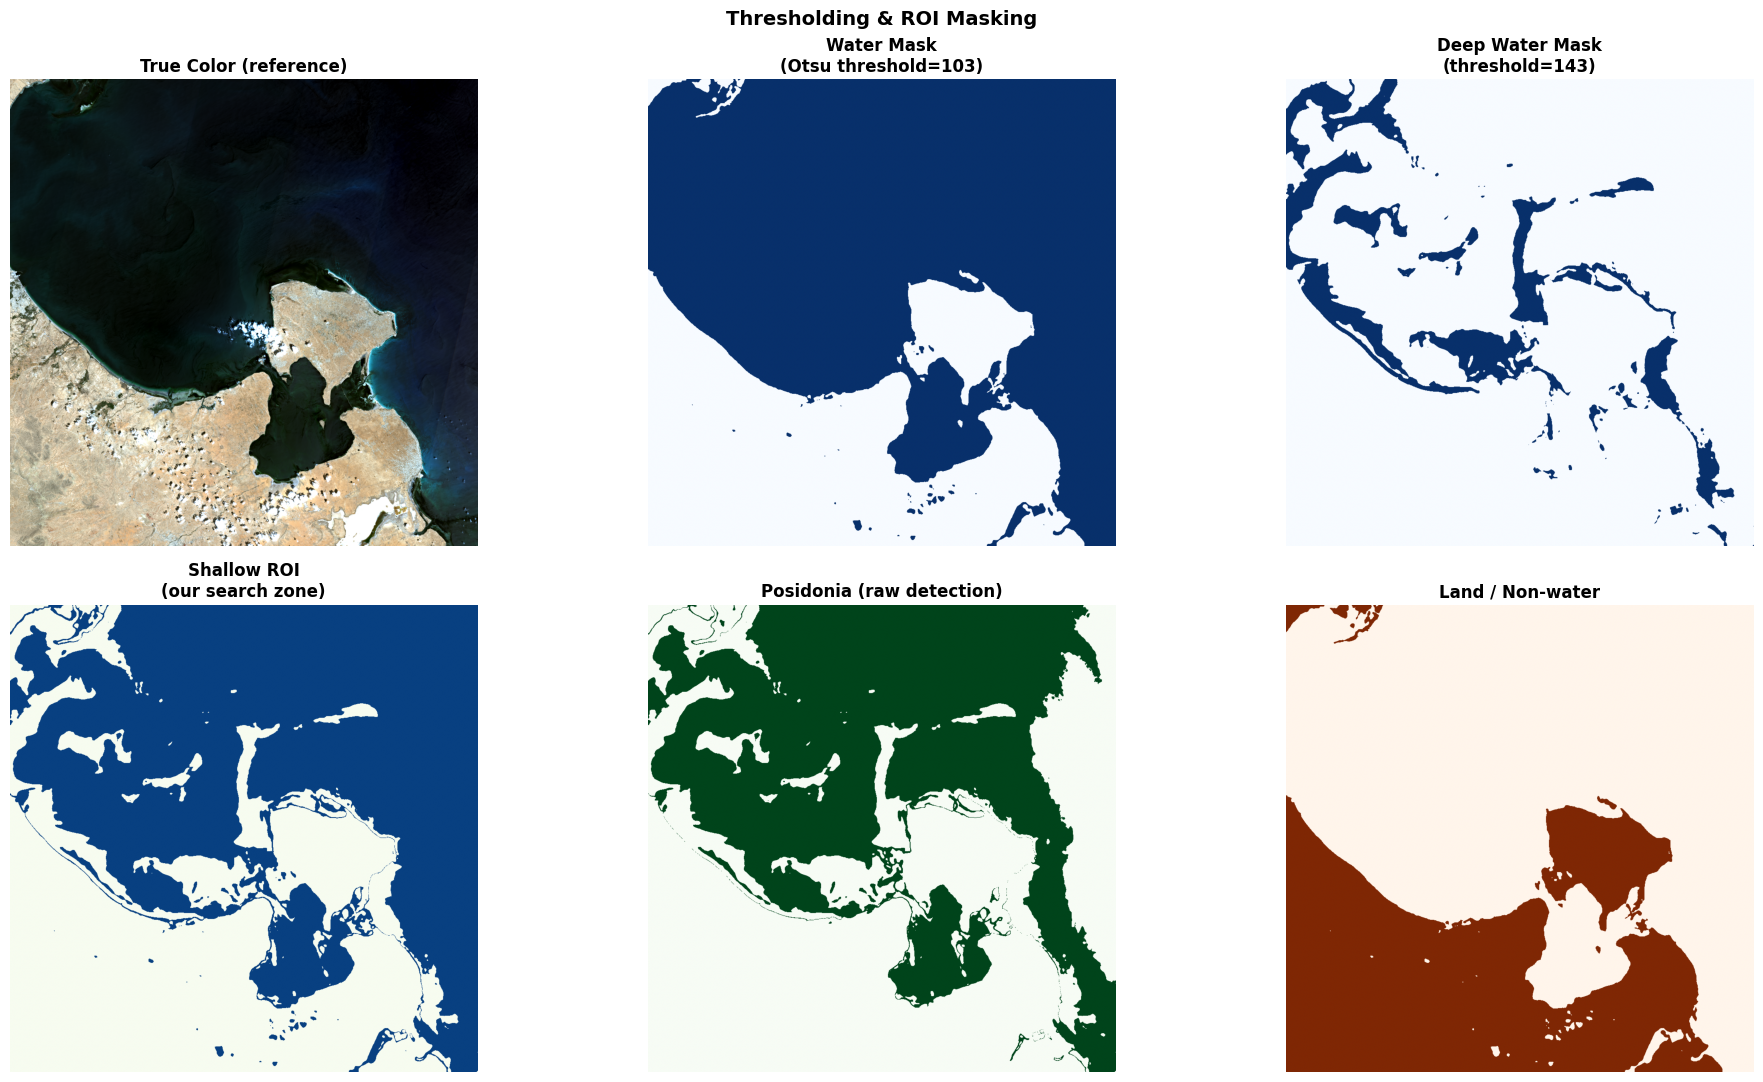

In [ ]:
#Water mask using Otsu thresholding on NDWI

otsu_val, water_mask = cv2.threshold(ndwi_filt, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  #Otsu  picks the best threshold
print(f'Otsu threshold for water: {int(otsu_val)} (out of 255)')

# Deep water mask (very high NDWI = open ocean)
deep_thresh = min(int(otsu_val) + 40, 230)
_, deep_mask = cv2.threshold(ndwi_filt, deep_thresh, 255, cv2.THRESH_BINARY)

# Shallow mask = our ROI
shallow_mask = cv2.subtract(water_mask, deep_mask) # Remove deep water from water

# Posidonia mask
# High NDVI inside the shallow zone only
NDVI_THRESHOLD = 128   # pixels above this value are considered vegetation
_, veg_mask = cv2.threshold(ndwi_filt, NDVI_THRESHOLD, 255, cv2.THRESH_BINARY)
posidonia_raw = cv2.bitwise_and(veg_mask, shallow_mask)

# Count detected pixels
pos_pixels = int(posidonia_raw.sum() // 255)
print(f'Raw Posidonia detection: {pos_pixels:,} pixels')


fig, axes = plt.subplots(2, 3, figsize=(20, 11))

panels = [
    (rgb,           'True Color (reference)',              None),
    (water_mask,    f'Water Mask\n(Otsu threshold={int(otsu_val)})', 'Blues'),
    (deep_mask,     f'Deep Water Mask\n(threshold={deep_thresh})',   'Blues'),
    (shallow_mask,  'Shallow ROI\n(our search zone)',                'GnBu'),
    (posidonia_raw, 'Posidonia (raw detection)',                     'Greens'),
    (cv2.bitwise_not(water_mask), 'Land / Non-water',               'Oranges'),
]

for ax, (img, title, cmap) in zip(axes.flat, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

plt.suptitle('Thresholding & ROI Masking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Before morphology: 556,425 px
After  morphology: 552,135 px  (4,290 noise pixels removed)
After  contour filter (>30px²): 566,474 px
Number of valid patches: 28


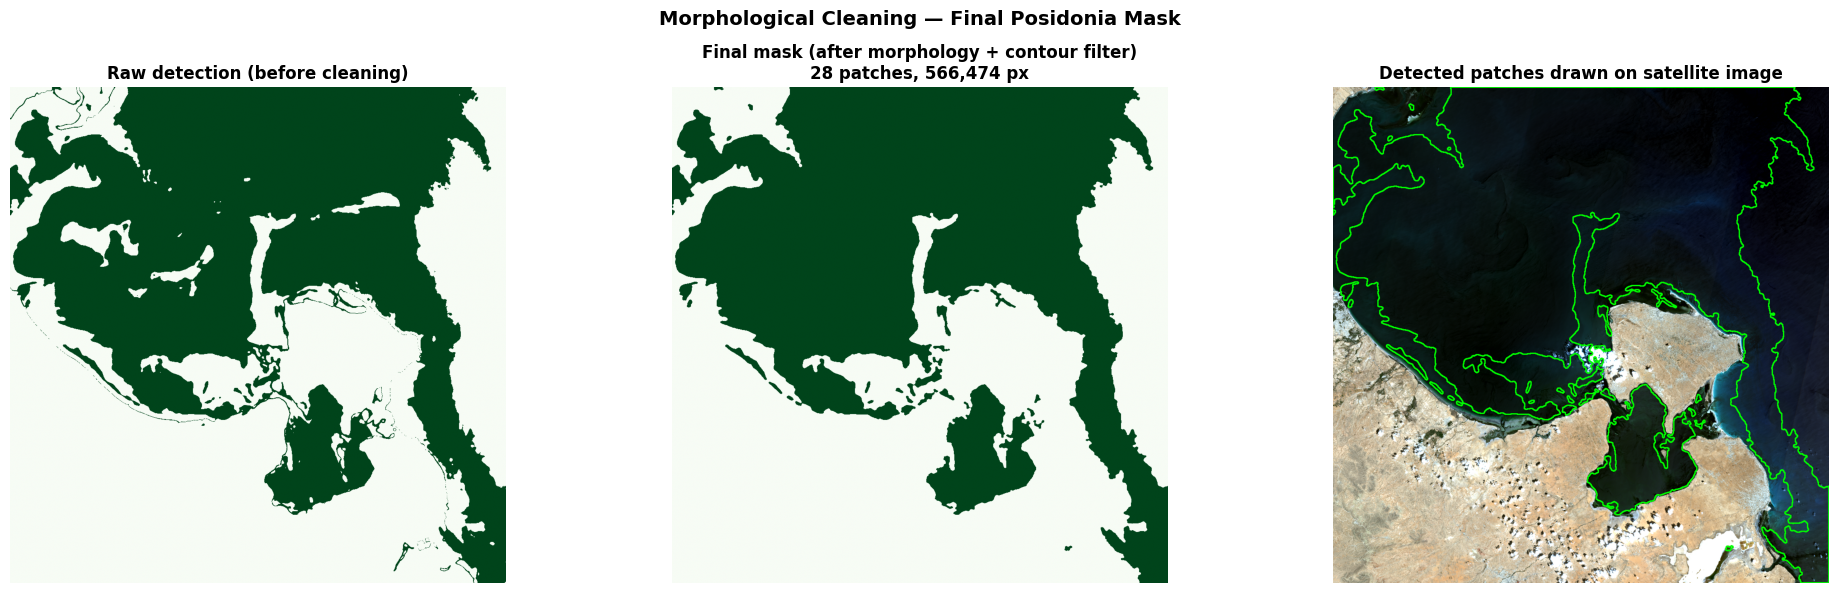

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))


posidonia_opened = cv2.morphologyEx(posidonia_raw, cv2.MORPH_OPEN, kernel) # removes small isolated noise pixels

posidonia_clean  = cv2.morphologyEx(posidonia_opened, cv2.MORPH_CLOSE, kernel)  # fills small holes inside detected patches

before = int(posidonia_raw.sum()   // 255)
after  = int(posidonia_clean.sum() // 255)
print(f'Before morphology: {before:,} px')
print(f'After  morphology: {after:,} px  ({before - after:,} noise pixels removed)')

# Filter out tiny patches (contour analysis)
MIN_AREA = 30
cnts, _ = cv2.findContours(posidonia_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
valid   = [c for c in cnts if cv2.contourArea(c) > MIN_AREA]
posidonia_final = np.zeros_like(posidonia_clean)
cv2.drawContours(posidonia_final, valid, -1, 255, -1)

final_px = int(posidonia_final.sum() // 255)
print(f'After  contour filter (>{MIN_AREA}px²): {final_px:,} px')
print(f'Number of valid patches: {len(valid)}')

rgb_u8 = (rgb * 255).astype(np.uint8)
rgb_contours = rgb_u8.copy()
cv2.drawContours(rgb_contours, valid, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(posidonia_raw,   cmap='Greens')
axes[0].set_title('Raw detection (before cleaning)', fontweight='bold')

axes[1].imshow(posidonia_final, cmap='Greens')
axes[1].set_title(f'Final mask (after morphology + contour filter)\n{len(valid)} patches, {final_px:,} px',
                  fontweight='bold')

axes[2].imshow(rgb_contours)
axes[2].set_title('Detected patches drawn on satellite image', fontweight='bold')

for ax in axes: ax.axis('off')
plt.suptitle('Morphological Cleaning — Final Posidonia Mask', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## SECTION 7: Morphological Cleaning


| Operation | Effect | Used for |
|---|---|---|
| **Erosion** | Shrinks white regions | Removes small noise pixels |
| **Dilation** | Expands white regions | Fills small gaps |
| **Opening** = Erosion then Dilation | Removes small noise | Clean mask ✓ |
| **Closing** = Dilation then Erosion | Fills holes | Smooth patches ✓ |
| **Gradient** = Dilation − Erosion | Finds edges | Visualize boundaries |


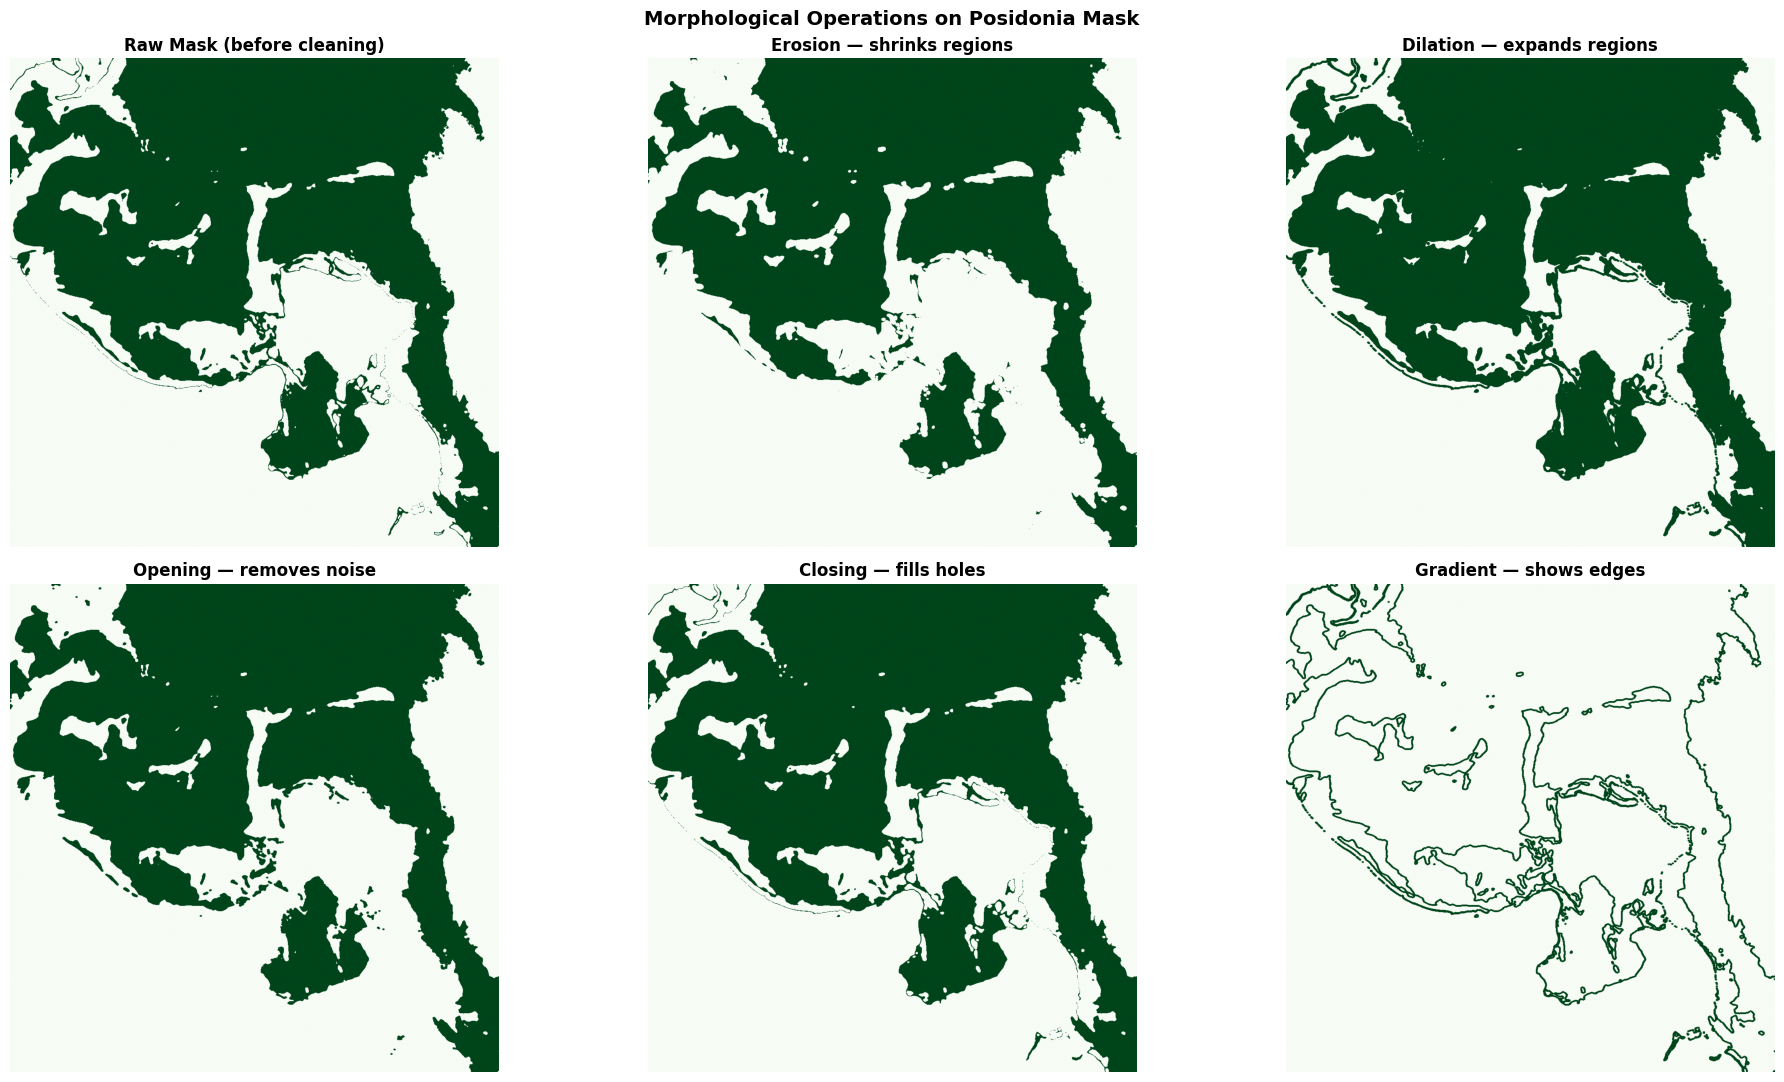

Before cleaning: 556,425 pixels
After  cleaning: 552,135 pixels  (difference = 4,290 noise pixels removed)


In [ ]:
# Define the kernel: an ellipse shape of 5x5 pixels
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Apply each morphological operation
pos_eroded   = cv2.erode(posidonia_raw, kernel, iterations=1)
pos_dilated  = cv2.dilate(posidonia_raw, kernel, iterations=1)
pos_opened   = cv2.morphologyEx(posidonia_raw, cv2.MORPH_OPEN,     kernel)
pos_closed   = cv2.morphologyEx(posidonia_raw, cv2.MORPH_CLOSE,    kernel)
pos_gradient = cv2.morphologyEx(posidonia_raw, cv2.MORPH_GRADIENT, kernel)

# Our final clean mask = Opening (removes noise) THEN Closing (fills holes)
posidonia_clean = cv2.morphologyEx(pos_opened, cv2.MORPH_CLOSE, kernel)


fig, axes = plt.subplots(2, 3, figsize=(20, 11))

panels = [
    (posidonia_raw,   'Raw Mask (before cleaning)'),
    (pos_eroded,      'Erosion — shrinks regions'),
    (pos_dilated,     'Dilation — expands regions'),
    (pos_opened,      'Opening — removes noise'),
    (pos_closed,      'Closing — fills holes'),
    (pos_gradient,    'Gradient — shows edges'),
]

for ax, (img, title) in zip(axes.flat, panels):
    ax.imshow(img, cmap='Greens')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

plt.suptitle('Morphological Operations on Posidonia Mask', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

before = int(posidonia_raw.sum() // 255)
after  = int(posidonia_clean.sum() // 255)
print(f'Before cleaning: {before:,} pixels')
print(f'After  cleaning: {after:,} pixels  (difference = {before - after:,} noise pixels removed)')


---
## SECTION 8:Edge Detection & Contour Analysis


Total contours found : 42
Valid contours (>30px²): 28

  ID   Area(px²)   Perimeter   Circularity       Shape
-------------------------------------------------------
   0       107.0        49.5        0.5497       Mixed
   1       143.0        89.6        0.2238   Elongated
   2       121.0        57.1        0.4662       Mixed
   3       391.0        93.3        0.5650       Mixed
   4        55.5        33.6        0.6194       Mixed
   5       108.0        50.3        0.5367       Mixed
   6        83.5        39.2        0.6824       Mixed
   7       124.0        53.5        0.5453       Mixed
   8       391.5       144.1        0.2368   Elongated
   9       321.0        94.9        0.4478       Mixed
  10        97.5        45.2        0.5994       Mixed
  11     36480.5      1644.9        0.1694   Elongated
  12       206.5        84.5        0.3637       Mixed
  13       140.0        63.5        0.4369       Mixed
  14      1226.5       278.8        0.1982   Elongated


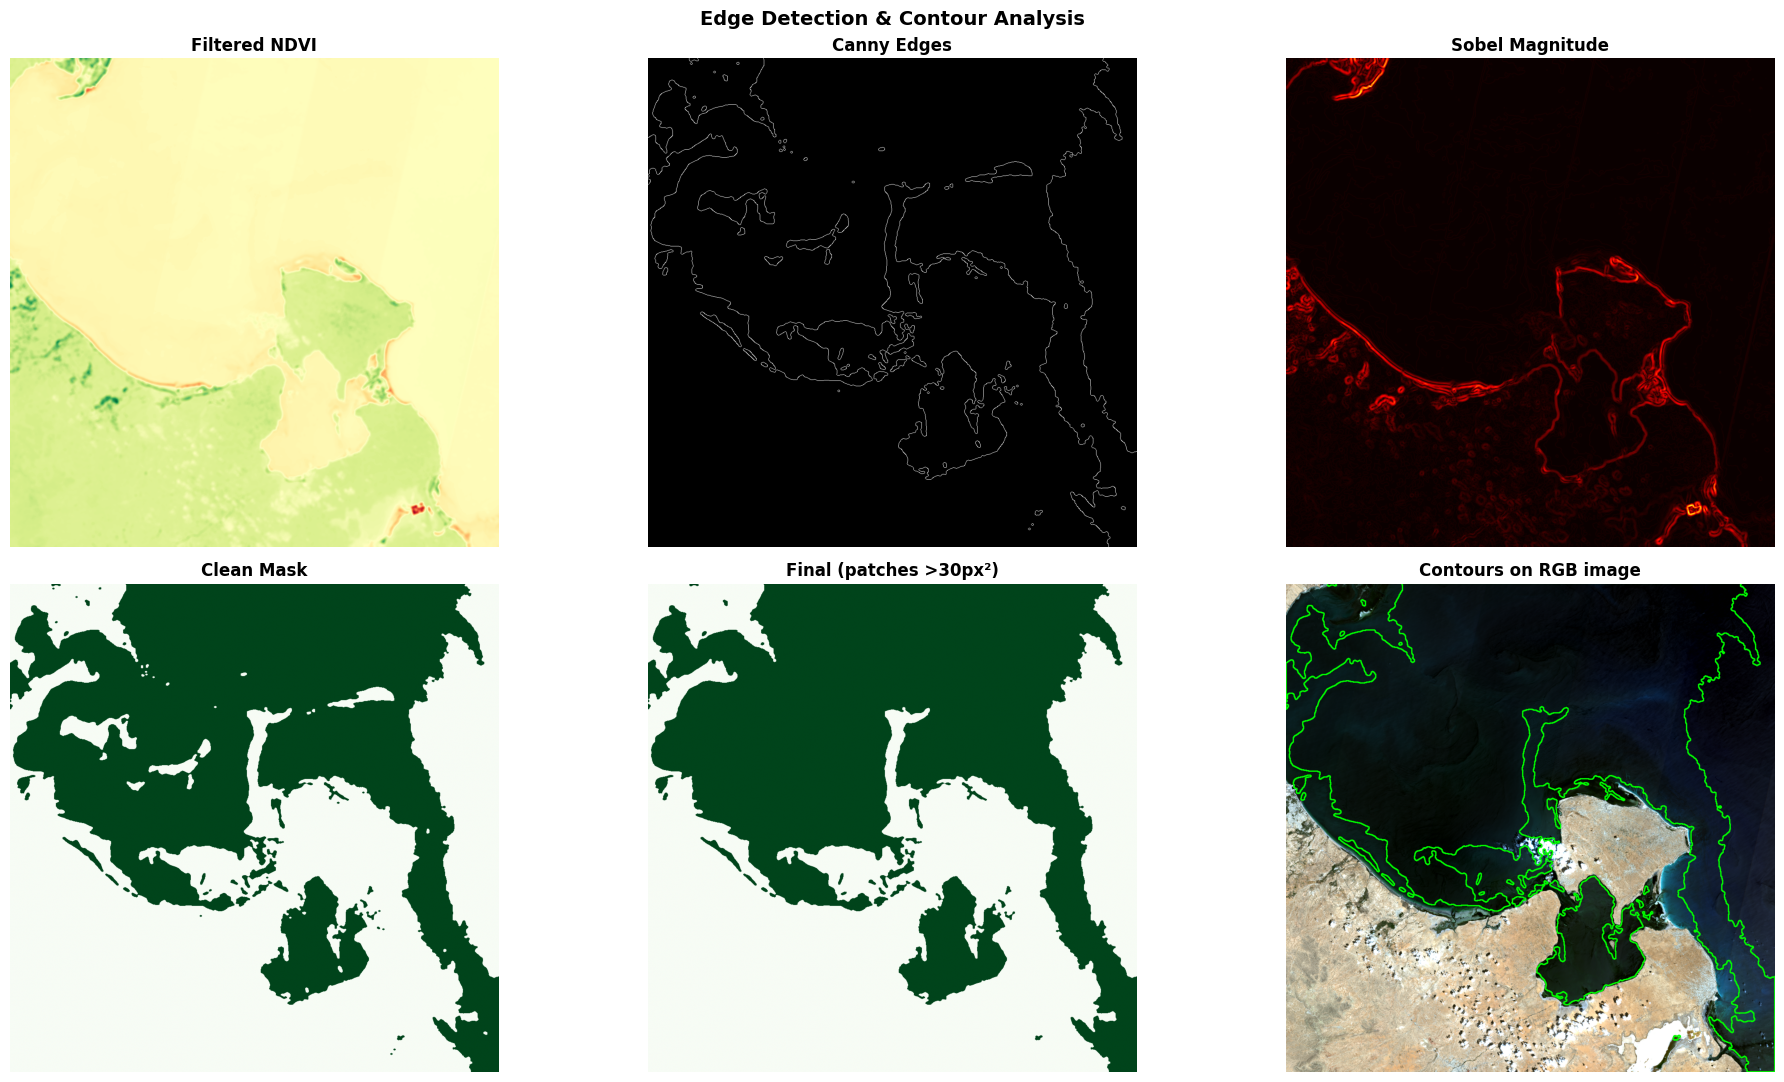

In [ ]:
MIN_AREA = 30   # ignore patches smaller than 30 pixels²

# Canny edge detection
#threshold1=50 (weak), threshold2=150 (strong)
edges_canny = cv2.Canny(posidonia_clean, 50, 150)

#  Sobel edge
sobel_x = cv2.Sobel(ndvi_filt, cv2.CV_64F, 1, 0, ksize=3)  # horizontal edges
sobel_y = cv2.Sobel(ndvi_filt, cv2.CV_64F, 0, 1, ksize=3)  # vertical edges
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)                # combined magnitude
sobel_mag = to_uint8(sobel_mag)                              # convert to display format

#Contour detection
contours, _ = cv2.findContours(posidonia_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Keep only patches bigger than MIN_AREA
valid_contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]

# Create final mask by drawing only valid contours (filled)
posidonia_final = np.zeros_like(posidonia_clean)
cv2.drawContours(posidonia_final, valid_contours, -1, 255, -1)

# shape analysis for each patch
print(f'Total contours found : {len(contours)}')
print(f'Valid contours (>{MIN_AREA}px²): {len(valid_contours)}')
print()
print(f'{"ID":>4}  {"Area(px²)":>10}  {"Perimeter":>10}  {"Circularity":>12}  {"Shape":>10}')
print('-' * 55)

for i, cnt in enumerate(valid_contours[:15]):   # show first 15
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt, closed=True)
    if peri == 0: continue
    circ  = 4 * np.pi * area / (peri ** 2)      # circularity formula
    shape = 'Round' if circ > 0.7 else ('Elongated' if circ < 0.3 else 'Mixed')
    print(f'{i:>4}  {area:>10.1f}  {peri:>10.1f}  {circ:>12.4f}  {shape:>10}')

# Draw contours on RGB for visualization
rgb_with_contours = rgb_u8.copy()
cv2.drawContours(rgb_with_contours, valid_contours, -1, (0, 255, 0), 2)  # green outlines

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
panels = [
    (ndvi_filt,          'Filtered NDVI',              'RdYlGn'),
    (edges_canny,        'Canny Edges',                'gray'),
    (sobel_mag,          'Sobel Magnitude',            'hot'),
    (posidonia_clean,    'Clean Mask',                 'Greens'),
    (posidonia_final,    f'Final (patches >{MIN_AREA}px²)', 'Greens'),
    (rgb_with_contours,  'Contours on RGB image',      None),
]

for ax, (img, title, cmap) in zip(axes.flat, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

plt.suptitle('Edge Detection & Contour Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## SECTION 9: Final Classification Map & Results Analysis



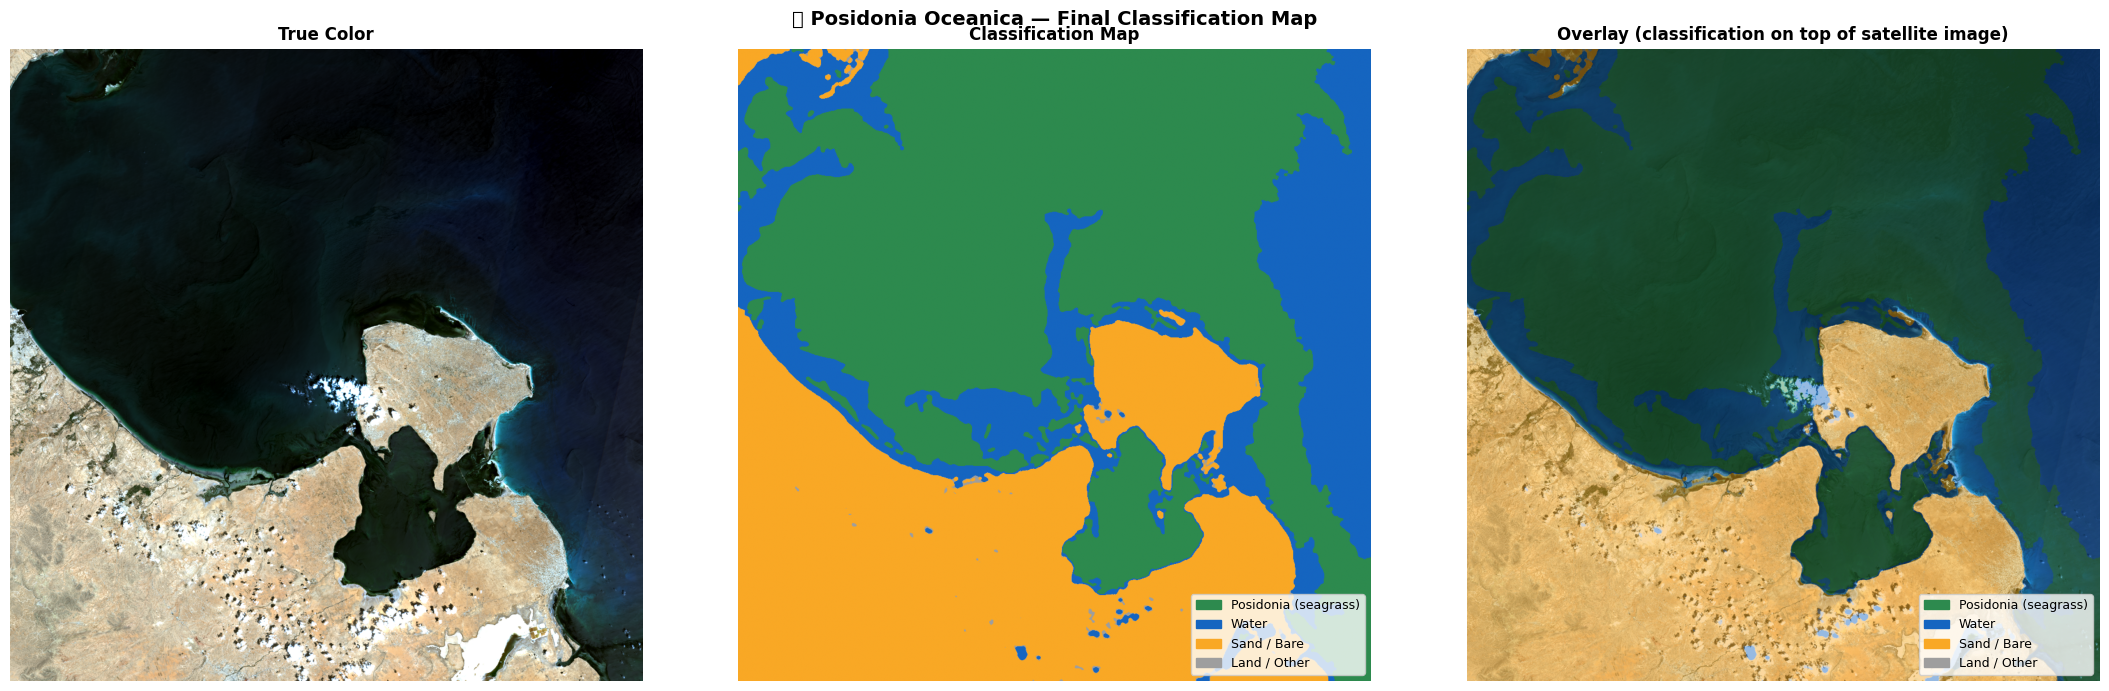

Classification Results
  [0] Posidonia (seagrass)     :  566,474 px  ( 47.0%)  ███████████████████████
  [1] Water                    :  240,322 px  ( 19.9%)  █████████
  [2] Sand / Bare              :  394,740 px  ( 32.7%)  ████████████████
  [3] Land / Other             :    4,068 px  (  0.3%)  



In [ ]:
# Build the water and sand masks for classification
kernel_lg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
water_clean = cv2.morphologyEx(
    cv2.morphologyEx(water_mask, cv2.MORPH_OPEN, kernel_lg),
    cv2.MORPH_CLOSE, kernel_lg
)

# Simple sand mask: low water signal + not water
_, sand_raw  = cv2.threshold(ndwi_filt, 100, 255, cv2.THRESH_BINARY_INV)
sand_mask    = cv2.bitwise_and(sand_raw, cv2.bitwise_not(water_mask))

# Start with everything = class 3 (Land/Other)
label_map = np.full(red.shape, 3, dtype=np.uint8)
label_map[sand_mask   > 0] = 2   # Sand
label_map[water_clean > 0] = 1   # Water
label_map[posidonia_final > 0] = 0   # Posidonia (drawn last = highest priority)

# Color scheme and class names
CLASS_NAMES  = ['Posidonia (seagrass)', 'Water', 'Sand / Bare', 'Land / Other']
CLASS_COLORS = ['#2d8a4e', '#1565c0', '#f9a825', '#9e9e9e']
cmap_cls  = plt.matplotlib.colors.ListedColormap(CLASS_COLORS)
legend_patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i]) for i in range(4)]

# Display: True Color | Classification Map | Overlay
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

axes[0].imshow(rgb)
axes[0].set_title('True Color', fontweight='bold')

axes[1].imshow(label_map, cmap=cmap_cls, vmin=0, vmax=3)
axes[1].set_title('Classification Map', fontweight='bold')
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=9)

axes[2].imshow(rgb)
axes[2].imshow(label_map, cmap=cmap_cls, vmin=0, vmax=3, alpha=0.45)
axes[2].set_title('Overlay (classification on top of satellite image)', fontweight='bold')
axes[2].legend(handles=legend_patches, loc='lower right', fontsize=9)

for ax in axes: ax.axis('off')
plt.suptitle('🌊 Posidonia Oceanica — Final Classification Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

total = label_map.size
print('Classification Results')
for i, name in enumerate(CLASS_NAMES):
    px  = int((label_map == i).sum())
    pct = 100 * px / total
    bar = '█' * int(pct / 2)
    print(f'  [{i}] {name:<25}: {px:>8,} px  ({pct:5.1f}%)  {bar}')
print()

In [ ]:
import numpy as np

np.savez_compressed(
    "posidonia_results.npz",
    blue=blue,
    green=green,
    red=red,
    nir=nir,
    ndvi=ndvi,
    ndwi=ndwi,
    ndvi_u8=ndvi_u8,
    ndwi_u8=ndwi_u8,
    ndvi_filt=ndvi_bilateral,        # the chosen bilateral filter output
    ndwi_filt=ndwi_filt,
    water_mask=water_mask,
    deep_mask=deep_mask,
    shallow_mask=shallow_mask,
    posidonia_raw=posidonia_raw,
    posidonia_clean=posidonia_clean,
    posidonia_final=posidonia_final,
    label_map=label_map,
    otsu_val=np.array([otsu_val]),
    deep_thresh=np.array([deep_thresh]),
)